In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD

In [15]:
df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
print("✅ 数据读取成功，共有行数:", len(df))
print("✅ 列名如下:")
print(df.columns.tolist())

✅ 数据读取成功，共有行数: 37053
✅ 列名如下:
['ID NR (anonymisert dummy)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'Bankkunde (1/0)', 'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET', 'BANK WALLET I MNOK', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mi

In [16]:
# df = df.drop(columns=['Bankkunde (1/0)','SUM UTLÅN','SUM RAMME','SUM INNSKUDD','BANK WALLET','BANK WALLET I MNOK', 'ID NR (anonymisert dummy)'])
df = df.drop(columns=['Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'SUM UTLÅN','SUM RAMME','SUM INNSKUDD','BANK WALLET', 'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)','Tilskudd i USD', 'Total Production Value(NOK)', 'Subsidy Dependency Ratio', 'Bransje'])
print(df.columns.tolist())
# 去除列名空格与特殊字符
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^0-9A-Za-z_]", "", regex=True)

# 替换 “ja/nei” 为 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})

# 将可能的目标列转换为数值
target_col = 'NY_tilskuddskategori'
df = df.dropna(subset=[target_col])  # 删除缺失值

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])  # 直接覆盖原列


['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Production Concentration Index', 'Subsidy_Zone']


C:\Users\21059\AppData\Local\Temp\ipykernel_6524\4148562548.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})


In [17]:
def generate_embeddings(df, prod_col='PRODUKSJON', region_cols=['Kommune', 'Fylke'],
                        prod_dim=16, region_dim=16):
    df = df.copy()
    
    # --- 1. PRODUKSJON 多标签编码 + SVD压缩 ---
    df[prod_col + '_list'] = df[prod_col].fillna("").apply(lambda x: [s.strip() for s in x.split(",") if s])
    mlb = MultiLabelBinarizer()
    prod_encoded = pd.DataFrame(mlb.fit_transform(df[prod_col + '_list']),
                                columns=mlb.classes_,
                                index=df.index)
    
    # SVD 压缩
    prod_svd = TruncatedSVD(n_components=prod_dim, random_state=42)
    prod_emb = prod_svd.fit_transform(prod_encoded)
    prod_emb_df = pd.DataFrame(prod_emb, columns=[f'PROD_emb_{i}' for i in range(prod_dim)],
                               index=df.index)
    
    # 合并回 df
    df = pd.concat([df, prod_emb_df], axis=1)
    df = df.drop(columns=[prod_col, prod_col + '_list'])
    
    # --- 2. 地区 + 行业编码 + SVD压缩 ---
    df_region = pd.get_dummies(df[region_cols], drop_first=True)
    
    region_svd = TruncatedSVD(n_components=region_dim, random_state=42)
    region_emb = region_svd.fit_transform(df_region)
    region_emb_df = pd.DataFrame(region_emb, columns=[f'REGION_emb_{i}' for i in range(region_dim)],
                                 index=df.index)
    
    # 合并回 df
    df = pd.concat([df, region_emb_df], axis=1)
    df = df.drop(columns=region_cols)
    
    return df

In [18]:
region_cols = ['Kommune', 'Fylke']
df = generate_embeddings(df, prod_col='PRODUKSJON', region_cols=region_cols,
                         prod_dim=16, region_dim=16)

print(df.columns.tolist())

# 输出基本信息
print(f"目标变量 '{target_col}' 值分布：")
print(df[target_col].value_counts())

['NY_tilskuddskategori', 'Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'Subsidy_Zone', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PR

In [19]:
agri_features = [
'Geit_dyr', 'Gress_dekar', 'Korn_dekar', 'Melk_dyr', 'Sau_dyr', 'Storfe_dyr']

# agri_features = ['Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PROD_emb_14', 'PROD_emb_15', 'REGION_emb_0', 'REGION_emb_1', 'REGION_emb_2', 'REGION_emb_3', 'REGION_emb_4', 'REGION_emb_5', 'REGION_emb_6', 'REGION_emb_7', 'REGION_emb_8', 'REGION_emb_9', 'REGION_emb_10', 'REGION_emb_11', 'REGION_emb_12', 'REGION_emb_13', 'REGION_emb_14', 'REGION_emb_15']
# agri_features = ['Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr']
X_graph = df[agri_features].values
y = df[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_graph)
# === 特征重要性加权 ===
important_features = {
    'Korn_dekar': 3.0,   # 权重系数，可根据 CatBoost importance 调整
    'Gress_dekar': 2.5,
    'Sau_dyr': 2.0,
    'Storfe_dyr': 1.8,
    'Melk_dyr': 1.5
}

# 找出这些特征在 agri_features 中的索引
for feat, w in important_features.items():
    if feat in agri_features:
        idx = agri_features.index(feat)
        X_scaled[:, idx] *= w

In [20]:
k = 250
threshold = 0.8
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# 转为相似度
similarities = 1 - distances
n = X_scaled.shape[0]
A = lil_matrix((n, n))

for i in range(n):
    for j, sim in zip(indices[i][1:], similarities[i][1:]):  # 跳过自己
        if sim > threshold:  # 可以加阈值
            A[i, j] = 1
            A[j, i] = 1
    if A[i].nnz == 0:
        j = indices[i][1]
        A[i, j] = 1
        A[j, i] = 1

In [21]:
degrees = np.array(A.sum(axis=1)).flatten()

print("每个节点的度：", degrees)
print("平均度：", degrees.mean())
print("度的标准差：", degrees.std())
print("中位度：", np.median(degrees))
print("最小度：", degrees.min())
print("最大度：", degrees.max())

每个节点的度： [365. 375. 349. ... 280. 348. 293.]
平均度： 316.5331012333684
度的标准差： 152.34902625965594
中位度： 301.0
最小度： 4.0
最大度： 2148.0


In [22]:
edge_index, edge_attr = from_scipy_sparse_matrix(A)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.float)
)


In [23]:
print(data)
print(f"节点数：{data.num_nodes}")
print(f"边数：{data.num_edges}")

Data(x=[37053, 6], edge_index=[2, 11728501], y=[37053])
节点数：37053
边数：11728501


In [24]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGEModel(in_channels=X_graph.shape[1], hidden=256, out_channels=4)

In [25]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# model.train()
# 
# epochs = 50
# for epoch in range(epochs):
#     optimizer.zero_grad()
#     out = model(X_tensor, edge_index_tensor)
# 
#     # L2 自监督：节点与邻居嵌入距离
#     row, col = edge_index_tensor
#     loss = ((out[row] - out[col])**2).sum() / row.size(0)
# 
#     loss.backward()
#     optimizer.step()
# 
#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}, Loss={loss.item():.4f}")

model.eval()
with torch.no_grad():
    embeddings = model(X_tensor, edge_index_tensor).numpy()
for i in range(embeddings.shape[1]):
    df[f"gnn_emb_{i}"] = embeddings[:, i]

C:\Users\21059\AppData\Local\Temp\ipykernel_6524\2760153432.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]


Train shape: (28850, 90), Test shape: (7213, 90)
Class distribution:
NY_tilskuddskategori
2    0.340737
1    0.240745
3    0.240385
0    0.178133
Name: proportion, dtype: float64 

=== Logistic Regression Model ===
✅ Logistic Regression Evaluation:
Accuracy: 0.34590323027866354
ROC AUC: 0.799636402031057

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.81      0.48      1285
           1       0.33      0.48      0.39      1736
           2       0.37      0.24      0.29      2458
           3       0.77      0.02      0.04      1734

    accuracy                           0.35      7213
   macro avg       0.45      0.39      0.30      7213
weighted avg       0.45      0.35      0.29      7213


=== Random Forest Model ===
✅ Random Forest Evaluation:
Accuracy: 0.8896436988770275
ROC AUC: 0.9840218698122453

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.9

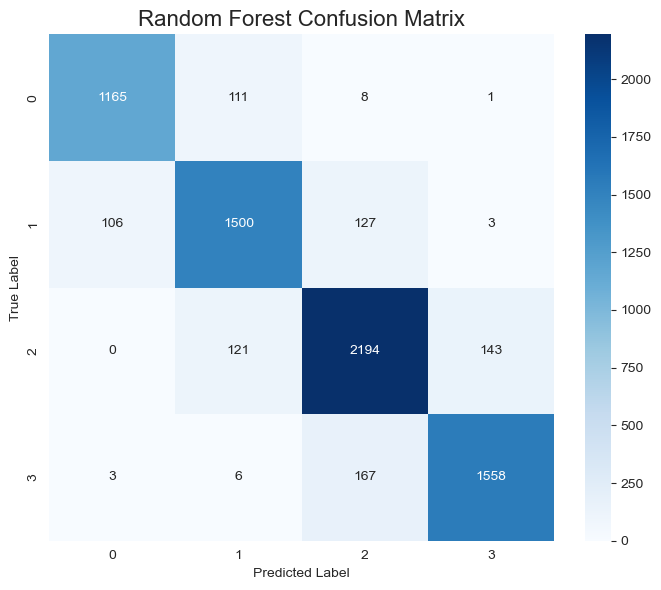


=== Feature Importance Analysis ===
Top 20 Important Features:
                           Feature  Importance
86                       gnn_emb_0    0.107957
89                       gnn_emb_3    0.100523
88                       gnn_emb_2    0.086251
87                       gnn_emb_1    0.081601
36                     Gress_dekar    0.060766
45                      Storfe_dyr    0.043772
52  Production_Concentration_Index    0.037219
42                        Melk_dyr    0.033140
54                      PROD_emb_0    0.029124
44                         Sau_dyr    0.028247
40                      Korn_dekar    0.024289
56                      PROD_emb_2    0.023820
26                          Storfe    0.023626
60                      PROD_emb_6    0.019126
66                     PROD_emb_12    0.018922
21                            Melk    0.017610
0           Kompleks_produksjon_10    0.016918
57                      PROD_emb_3    0.015831
61                      PROD_emb_7    0.015

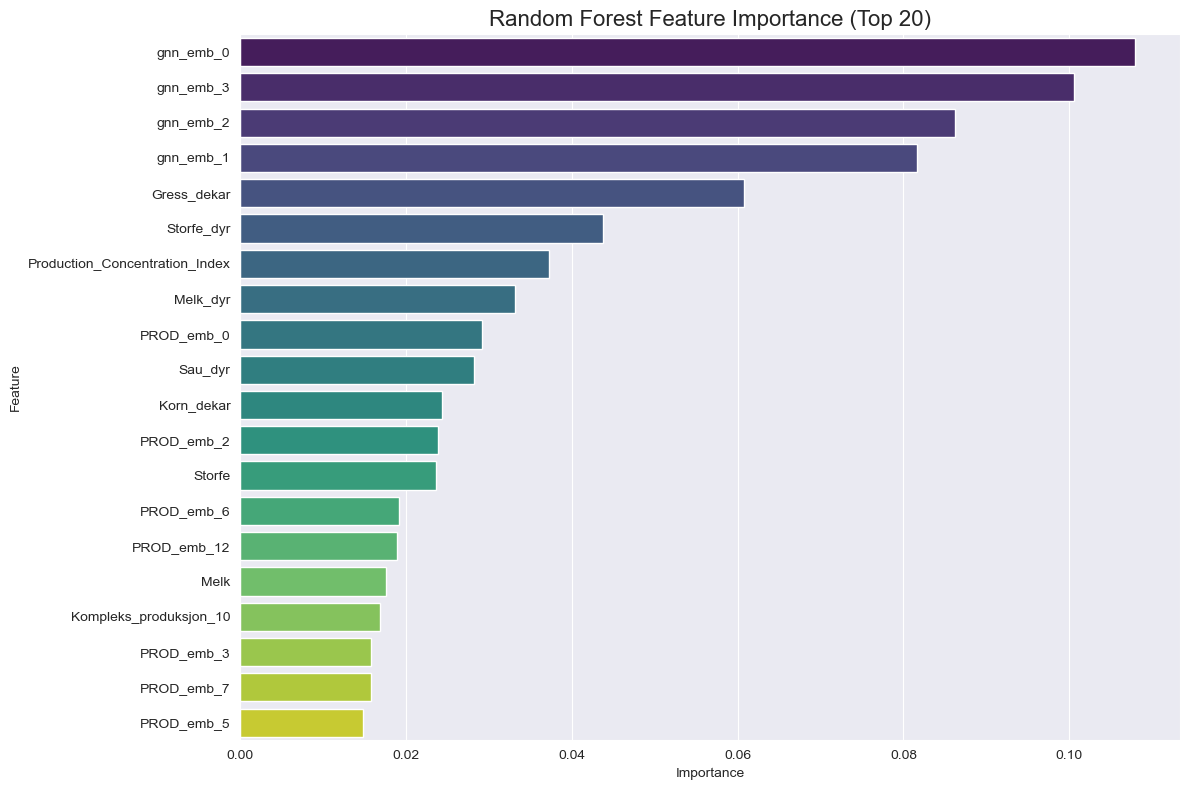

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, confusion_matrix
)

# --- 1. Prepare data ---
target_col = 'NY_tilskuddskategori'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Drop rows with NaN in features or target
X = X.dropna()
y = y.loc[X.index]  # 保持同步

# --- 2. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Class distribution:")
print(y.value_counts(normalize=True), "\n")

# --- 3a. Logistic Regression baseline ---
print("=== Logistic Regression Model ===")
log_reg = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    multi_class='multinomial',
    n_jobs=-1
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_pred_proba_lr = log_reg.predict_proba(X_test)

print("✅ Logistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
try:
    auc_lr = roc_auc_score(y_test, y_pred_proba_lr, multi_class='ovr')
    print("ROC AUC:", auc_lr)
except:
    print("ROC AUC could not be computed (too many or imbalanced classes)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# --- 3b. Random Forest baseline ---
print("\n=== Random Forest Model ===")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)

print("✅ Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
try:
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')
    print("ROC AUC:", auc_rf)
except:
    print("ROC AUC could not be computed (too many or imbalanced classes)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# --- 4. Confusion Matrix ---
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- 5. Feature Importance ---
print("\n=== Feature Importance Analysis ===")
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Important Features:")
print(importances.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importances.head(20),
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Random Forest Feature Importance (Top 20)', fontsize=16)
plt.tight_layout()
plt.show()
